In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',50)
pd.set_option('display.max_colwidth',80)

plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
df = pd.read_csv('../data/raw/Developer-survey-2025.csv',low_memory=False)
                 
print(f'shape:{df.shape}')
print(f'column count:{len(df.columns)}')
print(f'First 5 column names:{list(df.columns[:5])}')

shape:(49191, 172)
column count:172
First 5 column names:['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment']


In [4]:
list(df.columns[165:])

['AIAgentObsWrite',
 'AIAgentExternal',
 'AIAgentExtWrite',
 'AIHuman',
 'AIOpen',
 'ConvertedCompYearly',
 'JobSat']

In [5]:
target_col = 'ConvertedCompYearly'
print(f'Target column present: {target_col in df.columns}')

Target column present: True


In [6]:
salary_available = df[target_col].notna().sum() #not available
salary_missing = df[target_col].isna().sum()

print(f'rows with salary:{salary_available}')
print(f'rows without salary:{salary_missing}')
print(f'coverage:{salary_available/len(df)* 100:1f}%')

rows with salary:23947
rows without salary:25244
coverage:48.681669%


In [7]:
df[target_col].dropna().describe()

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

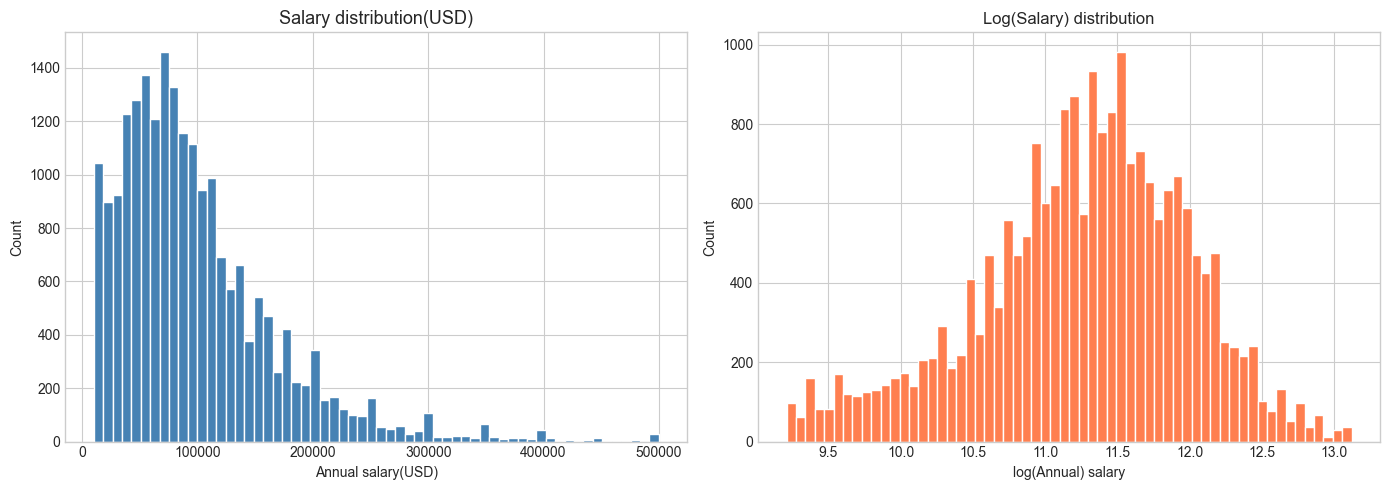

Median salary: $81,870
Mean salary: $98,572


In [8]:
salary_df = df[df[target_col].between(10000, 500000)]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
#raw distribution
axes[0].hist(salary_df[target_col], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Salary distribution(USD)', fontsize=13)
axes[0].set_xlabel('Annual salary(USD)')
axes[0].set_ylabel('Count')
 
#log-scale distribution
axes[1].hist(np.log1p(salary_df[target_col]), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Log(Salary) distribution')
axes[1].set_xlabel('log(Annual) salary')
axes[1].set_ylabel('Count')
 
plt.tight_layout()
plt.savefig('../data/salary_distribution.png',dpi=300) #saving the image in data folder, dpi= increases the quality of the image
plt.show()
 
print(f"Median salary: ${salary_df[target_col].median():,.0f}")
print(f'Mean salary: ${salary_df[target_col].mean():,.0f}')

In [9]:
# Explore selected features.
features = ['Country', 'YearsCodePro', 'Edlevel', 'Employment', 'LanguageHaveWorkedWith']


In [10]:
#Explore the selected features.
features = ['Country', 'YearsCodePro', 'Edlevel', 'Employment', 'LanguageHaveWorkedWith']
 
for col in features:
    if col in df.columns:
        missing_pct = df[col].isna().mean() * 100
        unique_count = df[col].nunique() #nunique - returns the number of unique items (int), .unique() returns the actual unique items.
 
        print("Column", col)
        print("Missing, ", missing_pct)
        print("Unique values count: ", unique_count)
        print(" First 5 rows: ")
        print(df[col].value_counts().head().to_string())
        print()

Column Country
Missing,  27.96039926002724
Unique values count:  177
 First 5 rows: 
Country
United States of America                                7233
Germany                                                 3025
India                                                   2547
United Kingdom of Great Britain and Northern Ireland    2042
France                                                  1409

Column Employment
Missing,  1.7320241507592853
Unique values count:  6
 First 5 rows: 
Employment
Employed                                                33750
Independent contractor, freelancer, or self-employed     6708
Student                                                  4428
Not employed                                             2227
Retired                                                   708

Column LanguageHaveWorkedWith
Missing,  35.6162712691346
Unique values count:  15478
 First 5 rows: 
LanguageHaveWorkedWith
HTML/CSS;JavaScript;TypeScript           370
Python                 

C:\Users\HomePC\AppData\Local\Temp\ipykernel_9804\384916242.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


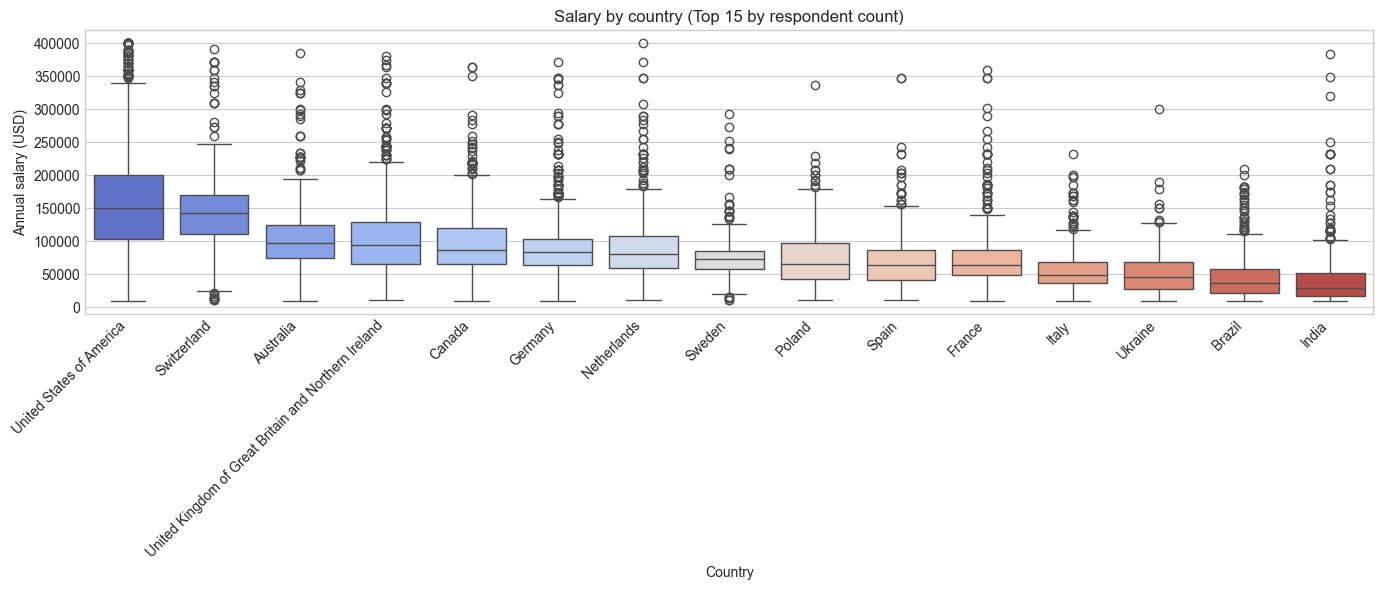

In [11]:
df_sal = df[df[target_col].between(10_000, 400_000)].copy()
 
df_sal = df[df[target_col].between(10_000, 400_000)].copy()
 
top_countries = df_sal['Country'].value_counts().head(15).index
country_data = df_sal[df_sal['Country'].isin(top_countries)]
 
plt.figure(figsize=(14, 6))
order = country_data.groupby('Country')[target_col].median().sort_values(ascending=False).index
 
sns.boxplot(
    data=country_data,
    x='Country', y=target_col,
    order=order,
    palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Salary by country (Top 15 by respondent count)')
plt.ylabel('Annual salary (USD)')
plt.tight_layout()
plt.savefig('../data/salary_by_country.png', dpi=300)
plt.show()



<Axes: >

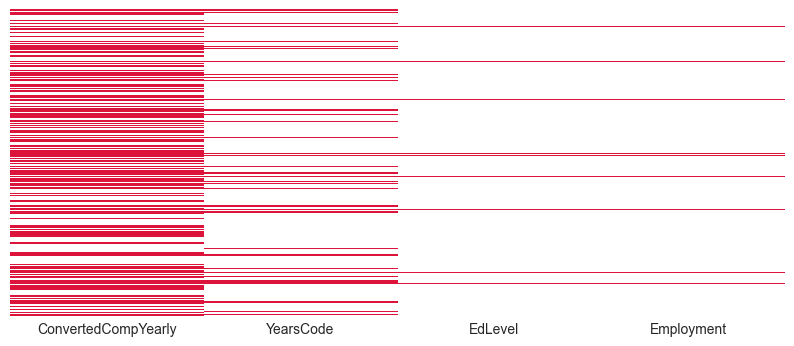

In [12]:
selected_cols = [target_col, 'country', 'YearsCode', 'EdLevel', 'Employment']
available_cols = [c for c in selected_cols if c in df.columns]

missing_df = df[available_cols].isna()

plt.figure(figsize=(10, 4))
sns.heatmap(missing_df.sample(min(1000, len(df)), random_state=42),
            cbar=False, yticklabels=False, xticklabels=True,
            cmap=['white', 'crimson'])



In [13]:
df['EdLevel'].unique()

<ArrowStringArray>
[                                   'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
                                                'Associate degree (A.A., A.S., etc.)',
                                       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
                             'Some college/university study without earning a degree',
                                     'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
 'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
                                                            'Other (please specify):',
                                                          'Primary/elementary school',
                                                                                  nan]
Length: 9, dtype: str

In [14]:
df['Employment'].unique()

<ArrowStringArray>
[                                            'Employed',
 'Independent contractor, freelancer, or self-employed',
                                              'Student',
                                              'Retired',
                                         'Not employed',
                                  'I prefer not to say',
                                                    nan]
Length: 7, dtype: str

In [15]:
df['LanguageHaveWorkedWith']

0                                                       Bash/Shell (all shells);Dart;SQL
1                                                                                   Java
2                                                    Dart;HTML/CSS;JavaScript;TypeScript
3                                                                        Java;Kotlin;SQL
4        C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;PowerShell;Python;SQL;TypeScrip...
                                              ...                                       
49186                                                                                NaN
49187                                                                                NaN
49188                                                                                NaN
49189                                                                                NaN
49190                                                                                NaN
Name: LanguageHaveWor

In [16]:
df['Country'].unique()

<ArrowStringArray>
[                 'Ukraine',              'Netherlands',
                    'India',                  'Georgia',
                'Australia',                   'Greece',
                  'Germany',               'Bangladesh',
                   'Brazil', 'United States of America',
 ...
                   'Gambia',                   'Malawi',
                    'Niger',                  'Lesotho',
               'San Marino',                 'Djibouti',
                  'Burundi',               'Cape Verde',
                    'Palau',                   'Guinea']
Length: 178, dtype: str

In [17]:
import os
import sys

#adding src to path to allow us import our module
sys.path.insert(0, os.path.dirname('../src/'))

from preprocessing import load_and_clean, get_feature_columns, TARGET

df = load_and_clean("../data/raw/Developer-survey-2025.csv")
df.to_csv("../data/cleaned/processed_data.csv", index=False)

Raw shape: (49191, 172) 

Shape after the salary filter: (21203, 172)
Selected 16 columns, expected 6 columns
Clean data shape: (21203, 16)
Missing values per column: 
 Country                      0
YearsCode                   67
EdLevel                      0
Employment                   0
DevType                      0
OrgSize                   2259
RemoteWork                2340
WorkExp                    248
Industry                   618
Age                          0
ICorPM                    2515
DatabaseHaveWorkedWith    4595
PlatformHaveWorkedWith    4951
ToolCountWork             3117
log_salary                   0
LanguageCount             1359 


In [18]:
df_cleaned = pd.read_csv("../data/cleaned/processed_data.csv")
print(df_cleaned.info())

<class 'pandas.DataFrame'>
RangeIndex: 21203 entries, 0 to 21202
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 21203 non-null  str    
 1   YearsCode               21136 non-null  float64
 2   EdLevel                 21203 non-null  str    
 3   Employment              21203 non-null  str    
 4   DevType                 21203 non-null  str    
 5   OrgSize                 18944 non-null  str    
 6   RemoteWork              18863 non-null  str    
 7   WorkExp                 20955 non-null  float64
 8   Industry                20585 non-null  str    
 9   Age                     21203 non-null  str    
 10  ICorPM                  18688 non-null  str    
 11  DatabaseHaveWorkedWith  16608 non-null  str    
 12  PlatformHaveWorkedWith  16252 non-null  str    
 13  ToolCountWork           18086 non-null  float64
 14  log_salary              21203 non-null  float64
 